In [1]:
# ============================================
# MODULE 2: SENTIMENT ANALYSIS
# ============================================

%pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================
# IMPORTS
# ============================================

import pandas as pd
import re
import nltk
import warnings
warnings.filterwarnings('ignore')

from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    nltk.download('vader_lexicon')

In [3]:
# ============================================
# STEP 1: LOAD AND COMBINE ALL DATASETS
# ============================================

print("="*60)
print("LOADING AND COMBINING DATASETS")
print("="*60)

datasets = []

# 1. Load fake.csv
try:
    fake = pd.read_csv("../datasets/fake.csv")
    fake['label'] = 0  # 0 = Fake
    fake['source'] = 'fake'
    datasets.append(fake)
    print(f"✓ Loaded fake.csv: {fake.shape[0]:,} rows")
except Exception as e:
    print(f"✗ Could not load fake.csv: {e}")

# 2. Load True.csv
try:
    true = pd.read_csv("../datasets/True.csv")
    true['label'] = 1  # 1 = True
    true['source'] = 'true'
    datasets.append(true)
    print(f"✓ Loaded True.csv: {true.shape[0]:,} rows")
except Exception as e:
    print(f"✗ Could not load True.csv: {e}")

# 3. Load AG_Train.csv
try:
    ag_train = pd.read_csv("../datasets/AG_Train.csv")
    print(f"AG_Train columns: {ag_train.columns.tolist()}")
    
    # Map labels: 3,4 = True (1), others = Fake (0)
    if 'Class Index' in ag_train.columns:
        ag_train['label'] = ag_train['Class Index'].apply(lambda x: 1 if x in [3, 4] else 0)
    elif 'class' in ag_train.columns:
        ag_train['label'] = ag_train['class'].apply(lambda x: 1 if x in [3, 4] else 0)
    elif 'label' in ag_train.columns:
        ag_train['label'] = ag_train['label'].apply(lambda x: 1 if x in [3, 4] else 0)
    else:
        first_col = ag_train.columns[0]
        ag_train['label'] = ag_train[first_col].apply(lambda x: 1 if x in [3, 4] else 0)
    
    # Combine Title and Description into one text column
    if 'Title' in ag_train.columns and 'Description' in ag_train.columns:
        ag_train['text'] = ag_train['Title'].fillna('') + ' ' + ag_train['Description'].fillna('')
    elif 'title' in ag_train.columns and 'description' in ag_train.columns:
        ag_train['text'] = ag_train['title'].fillna('') + ' ' + ag_train['description'].fillna('')
    elif len(ag_train.columns) >= 3:
        col_names = ag_train.columns.tolist()
        ag_train['text'] = ag_train[col_names[1]].fillna('') + ' ' + ag_train[col_names[2]].fillna('')
    else:
        text_col = ag_train.columns[1] if len(ag_train.columns) > 1 else ag_train.columns[0]
        ag_train['text'] = ag_train[text_col]
    
    ag_train['source'] = 'AG_Train'
    datasets.append(ag_train)
    print(f"✓ Loaded AG_Train.csv: {ag_train.shape[0]:,} rows")
except Exception as e:
    print(f"✗ Could not load AG_Train.csv: {e}")

# 4. Load AG_Test.csv
try:
    ag_test = pd.read_csv("../datasets/AG_Test.csv")
    print(f"AG_Test columns: {ag_test.columns.tolist()}")
    
    if 'Class Index' in ag_test.columns:
        ag_test['label'] = ag_test['Class Index'].apply(lambda x: 1 if x in [3, 4] else 0)
    elif 'class' in ag_test.columns:
        ag_test['label'] = ag_test['class'].apply(lambda x: 1 if x in [3, 4] else 0)
    elif 'label' in ag_test.columns:
        ag_test['label'] = ag_test['label'].apply(lambda x: 1 if x in [3, 4] else 0)
    else:
        first_col = ag_test.columns[0]
        ag_test['label'] = ag_test[first_col].apply(lambda x: 1 if x in [3, 4] else 0)
    
    if 'Title' in ag_test.columns and 'Description' in ag_test.columns:
        ag_test['text'] = ag_test['Title'].fillna('') + ' ' + ag_test['Description'].fillna('')
    elif 'title' in ag_test.columns and 'description' in ag_test.columns:
        ag_test['text'] = ag_test['title'].fillna('') + ' ' + ag_test['description'].fillna('')
    elif len(ag_test.columns) >= 3:
        col_names = ag_test.columns.tolist()
        ag_test['text'] = ag_test[col_names[1]].fillna('') + ' ' + ag_test[col_names[2]].fillna('')
    else:
        text_col = ag_test.columns[1] if len(ag_test.columns) > 1 else ag_test.columns[0]
        ag_test['text'] = ag_test[text_col]
    
    ag_test['source'] = 'AG_Test'
    datasets.append(ag_test)
    print(f"✓ Loaded AG_Test.csv: {ag_test.shape[0]:,} rows")
except Exception as e:
    print(f"✗ Could not load AG_Test.csv: {e}")

# Combine all datasets
df = pd.concat(datasets, ignore_index=True)

print("-"*60)
print(f"Total combined rows: {len(df):,}")
print(f"Columns in dataset: {df.columns.tolist()}")

LOADING AND COMBINING DATASETS
✓ Loaded fake.csv: 23,481 rows
✓ Loaded True.csv: 21,417 rows
AG_Train columns: ['Class Index', 'Title', 'Description']
✓ Loaded AG_Train.csv: 120,000 rows
AG_Test columns: ['Class Index', 'Title', 'Description']
✓ Loaded AG_Test.csv: 7,600 rows
------------------------------------------------------------
Total combined rows: 172,498
Columns in dataset: ['title', 'text', 'subject', 'date', 'label', 'source', 'Class Index', 'Title', 'Description']


In [4]:
# ============================================
# STEP 2: SENTIMENT ANALYSIS FUNCTION
# ============================================

def get_sentiment(text):
    """
    Get sentiment polarity using TextBlob
    
    Parameters:
    -----------
    text : str
        Text to analyze
        
    Returns:
    --------
    str : 'Positive', 'Negative', or 'Neutral'
    """
    if pd.isna(text) or str(text).strip() == '':
        return 'Neutral'
    
    try:
        blob = TextBlob(str(text))
        polarity = blob.sentiment.polarity
        
        if polarity > 0.1:
            return "Positive"
        elif polarity < -0.1:
            return "Negative"
        else:
            return "Neutral"
    except:
        return "Neutral"

In [5]:
# ============================================
# STEP 3: TEST THE FUNCTION
# ============================================

print("="*60)
print("TESTING SENTIMENT FUNCTION")
print("="*60)

test_texts = [
    "I am very happy today",
    "This is a terrible disaster",
    "Pakistan won the match",
    "Thousands of people died",
    "Government announced policy"
]

for text in test_texts:
    sentiment = get_sentiment(text)
    print(f"Text: {text}")
    print(f"Sentiment: {sentiment}")
    print("-"*40)

TESTING SENTIMENT FUNCTION
Text: I am very happy today
Sentiment: Positive
----------------------------------------
Text: This is a terrible disaster
Sentiment: Negative
----------------------------------------
Text: Pakistan won the match
Sentiment: Neutral
----------------------------------------
Text: Thousands of people died
Sentiment: Neutral
----------------------------------------
Text: Government announced policy
Sentiment: Neutral
----------------------------------------


In [6]:
# ============================================
# STEP 4: APPLY SENTIMENT ANALYSIS TO ALL DATA
# ============================================

print("\n" + "="*60)
print("APPLYING SENTIMENT ANALYSIS")
print("="*60)

# Apply sentiment to all text
print("Analyzing sentiment for all articles...")
df["sentiment"] = df["text"].apply(get_sentiment)

# Show distribution
print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())
print("\nPercentage Distribution:")
print(df["sentiment"].value_counts(normalize=True) * 100)


APPLYING SENTIMENT ANALYSIS
Analyzing sentiment for all articles...

Sentiment Distribution:
sentiment
Neutral     97039
Positive    56622
Negative    18837
Name: count, dtype: int64

Percentage Distribution:
sentiment
Neutral     56.255145
Positive    32.824728
Negative    10.920127
Name: proportion, dtype: float64


In [7]:
# ============================================
# STEP 5: EXPLORE SENTIMENT BY LABEL
# ============================================

print("\n" + "="*60)
print("SENTIMENT BY LABEL")
print("="*60)

# Cross-tabulation of sentiment and label
sentiment_by_label = pd.crosstab(df['sentiment'], df['label'])
print("Sentiment by Label (0=Fake, 1=True):")
print(sentiment_by_label)

# Percentage by label
sentiment_percent = pd.crosstab(df['sentiment'], df['label'], normalize='columns') * 100
print("\nPercentage by Label:")
print(sentiment_percent)

# Show examples
print("\nExample articles by sentiment:")
print("-"*60)

for sentiment_type in ['Positive', 'Negative', 'Neutral']:
    examples = df[df['sentiment'] == sentiment_type]['text'].head(2)
    print(f"\n{sentiment_type} Examples:")
    for i, text in enumerate(examples, 1):
        print(f"  {i}. {text[:100]}...")


SENTIMENT BY LABEL
Sentiment by Label (0=Fake, 1=True):
label          0      1
sentiment              
Negative   10966   7871
Neutral    47938  49101
Positive   28377  28245

Percentage by Label:
label              0          1
sentiment                      
Negative   12.564017   9.236420
Neutral    54.923752  57.618785
Positive   32.512231  33.144795

Example articles by sentiment:
------------------------------------------------------------

Positive Examples:
  1. Republicans are working overtime trying to sell their scam of a tax bill to the public as something ...
  2. Republicans have had seven years to come up with a viable replacement for Obamacare but they failed ...

Negative Examples:
  1. Donald Trump s current deputy national security adviser K.T. McFarland, a former Fox News personalit...
  2. Donald Trump retweeted fake news videos in the early hours of the morning and for that, he was widel...

Neutral Examples:
  1. Donald Trump just couldn t wish all Americans a 

In [8]:
# ============================================
# STEP 6: SENTIMENT BY SOURCE
# ============================================

print("\n" + "="*60)
print("SENTIMENT BY DATASET SOURCE")
print("="*60)

sentiment_by_source = pd.crosstab(df['source'], df['sentiment'])
print("Sentiment by Source:")
print(sentiment_by_source)

# Visualize with percentages
sentiment_source_percent = pd.crosstab(df['source'], df['sentiment'], normalize='index') * 100
print("\nSentiment Percentage by Source:")
print(sentiment_source_percent)


SENTIMENT BY DATASET SOURCE
Sentiment by Source:
sentiment  Negative  Neutral  Positive
source                                
AG_Test        1004     4005      2591
AG_Train      15905    62585     41510
fake           1155    15176      7150
true            773    15273      5371

Sentiment Percentage by Source:
sentiment   Negative    Neutral   Positive
source                                    
AG_Test    13.210526  52.697368  34.092105
AG_Train   13.254167  52.154167  34.591667
fake        4.918871  64.630978  30.450151
true        3.609282  71.312509  25.078209


In [9]:
# ============================================
# STEP 7: SAVE RESULTS
# ============================================

print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Save full dataset with sentiment
df.to_csv("news_with_sentiment.csv", index=False)
print("✓ Saved full dataset to: news_with_sentiment.csv")

# Save summary statistics
summary = df.groupby(['label', 'sentiment']).size().unstack(fill_value=0)
summary.to_csv("sentiment_summary.csv")
print("✓ Saved summary to: sentiment_summary.csv")

print(f"\nFinal dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


SAVING RESULTS
✓ Saved full dataset to: news_with_sentiment.csv
✓ Saved summary to: sentiment_summary.csv

Final dataset shape: (172498, 10)
Columns: ['title', 'text', 'subject', 'date', 'label', 'source', 'Class Index', 'Title', 'Description', 'sentiment']



VISUALIZATIONS


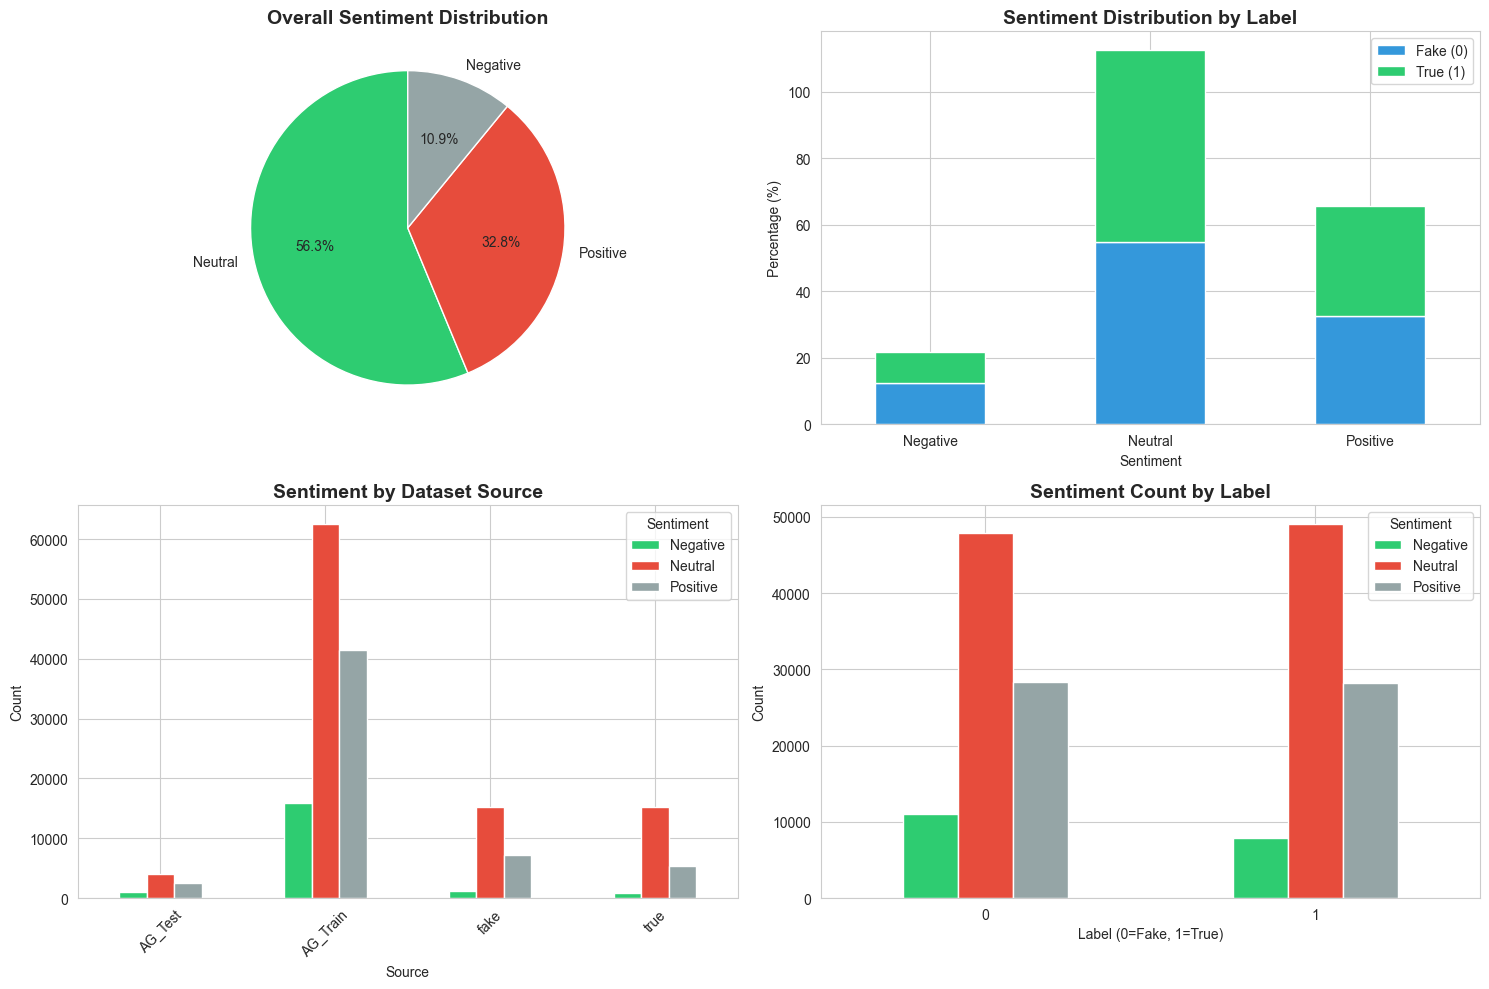

✓ Visualization saved to: sentiment_analysis_visualization.png


In [10]:
# ============================================
# STEP 8: VISUALIZATION (Optional but Impressive)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("VISUALIZATIONS")
print("="*60)

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

# 1. Overall Sentiment Distribution
plt.subplot(2, 2, 1)
sentiment_counts = df['sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
plt.title('Overall Sentiment Distribution', fontsize=14, fontweight='bold')

# 2. Sentiment by Label
plt.subplot(2, 2, 2)
sentiment_by_label = pd.crosstab(df['sentiment'], df['label'], normalize='columns') * 100
sentiment_by_label.plot(kind='bar', stacked=True, ax=plt.gca(), 
                        color=['#3498db', '#2ecc71'])
plt.title('Sentiment Distribution by Label', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Percentage (%)')
plt.legend(['Fake (0)', 'True (1)'])
plt.xticks(rotation=0)

# 3. Sentiment by Source
plt.subplot(2, 2, 3)
sentiment_by_source = pd.crosstab(df['source'], df['sentiment'])
sentiment_by_source.plot(kind='bar', ax=plt.gca(), 
                        color=['#2ecc71', '#e74c3c', '#95a5a6'])
plt.title('Sentiment by Dataset Source', fontsize=14, fontweight='bold')
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')

# 4. Count of Positive vs Negative by Label
plt.subplot(2, 2, 4)
sentiment_count = df.groupby(['label', 'sentiment']).size().unstack(fill_value=0)
sentiment_count.plot(kind='bar', ax=plt.gca(), 
                     color=['#2ecc71', '#e74c3c', '#95a5a6'])
plt.title('Sentiment Count by Label', fontsize=14, fontweight='bold')
plt.xlabel('Label (0=Fake, 1=True)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')

plt.tight_layout()
plt.savefig('sentiment_analysis_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Visualization saved to: sentiment_analysis_visualization.png")

In [11]:
# ============================================
# STEP 9: MORE DETAILED ANALYSIS
# ============================================

print("\n" + "="*60)
print("DETAILED ANALYSIS")
print("="*60)

# Analyze polarity scores (not just categories)
def get_polarity(text):
    """Get exact polarity score"""
    if pd.isna(text) or str(text).strip() == '':
        return 0.0
    try:
        blob = TextBlob(str(text))
        return blob.sentiment.polarity
    except:
        return 0.0

df['polarity_score'] = df['text'].apply(get_polarity)

# Statistics by label
print("Polarity Statistics by Label:")
print(df.groupby('label')['polarity_score'].describe())

# Most positive and negative articles
print("\nTop 5 Most Positive Articles:")
positive_articles = df.nlargest(5, 'polarity_score')[['text', 'polarity_score', 'label', 'source']]
for idx, row in positive_articles.iterrows():
    print(f"  Score: {row['polarity_score']:.3f} | Label: {row['label']} | {row['text'][:80]}...")

print("\nTop 5 Most Negative Articles:")
negative_articles = df.nsmallest(5, 'polarity_score')[['text', 'polarity_score', 'label', 'source']]
for idx, row in negative_articles.iterrows():
    print(f"  Score: {row['polarity_score']:.3f} | Label: {row['label']} | {row['text'][:80]}...")


DETAILED ANALYSIS
Polarity Statistics by Label:
         count      mean       std  min       25%       50%       75%  max
label                                                                     
0      87281.0  0.057813  0.187108 -1.0 -0.017471  0.032970  0.138406  1.0
1      85217.0  0.065243  0.165824 -1.0  0.000000  0.045455  0.136364  1.0

Top 5 Most Positive Articles:
  Score: 1.000 | Label: 0 | AWESOME! @KellyannePolls : I m Not A Sore Winner,I m A Winner!Our Champion is @r...
  Score: 1.000 | Label: 0 | This is diversity! These people are awesome!...
  Score: 1.000 | Label: 0 | Rudy is the best! He stays on message and was there when the Trump speech and co...
  Score: 1.000 | Label: 0 | Donald trump was making the rounds at a Colorado Springs campaign event and did ...
  Score: 1.000 | Label: 0 | This has to be one of the best remix videos ever! It gets to the heart of the ca...

Top 5 Most Negative Articles:
  Score: -1.000 | Label: 0 | THIS IS OUTRAGEOUS! YOU WON T BELIEV

In [12]:
# ============================================
# STEP 10: QUICK PREDICTION FUNCTION
# ============================================

def analyze_sentiment(text):
    """
    Quick function to analyze sentiment of any text
    
    Parameters:
    -----------
    text : str
        Text to analyze
        
    Returns:
    --------
    dict : Sentiment result with details
    """
    if pd.isna(text) or str(text).strip() == '':
        return {'sentiment': 'Neutral', 'polarity': 0.0, 'subjectivity': 0.0}
    
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    
    if polarity > 0.1:
        sentiment = "Positive"
    elif polarity < -0.1:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    
    return {
        'sentiment': sentiment,
        'polarity': polarity,
        'subjectivity': subjectivity
    }

# Test the function
print("="*60)
print("TESTING SENTIMENT ANALYSIS")
print("="*60)

test_articles = [
    "I love this beautiful day!",
    "This is the worst news ever!",
    "The government announced a new policy today.",
    "Imran Khan is alive and well",
    "Pakistan wins the match!",
    "Thousands died in the earthquake.",
]

for article in test_articles:
    result = analyze_sentiment(article)
    print(f"\nText: {article}")
    print(f"Sentiment: {result['sentiment']}")
    print(f"Polarity: {result['polarity']:.3f}")
    print(f"Subjectivity: {result['subjectivity']:.3f}")
    print("-"*40)

TESTING SENTIMENT ANALYSIS

Text: I love this beautiful day!
Sentiment: Positive
Polarity: 0.750
Subjectivity: 0.800
----------------------------------------

Text: This is the worst news ever!
Sentiment: Negative
Polarity: -1.000
Subjectivity: 1.000
----------------------------------------

Text: The government announced a new policy today.
Sentiment: Positive
Polarity: 0.136
Subjectivity: 0.455
----------------------------------------

Text: Imran Khan is alive and well
Sentiment: Neutral
Polarity: 0.100
Subjectivity: 0.400
----------------------------------------

Text: Pakistan wins the match!
Sentiment: Positive
Polarity: 0.375
Subjectivity: 0.200
----------------------------------------

Text: Thousands died in the earthquake.
Sentiment: Neutral
Polarity: 0.000
Subjectivity: 0.000
----------------------------------------


In [16]:
# ============================================
# STEP 11: SENTIMENT ANALYSIS BY FAKE/TRUE NEWS
# ============================================

print("\n" + "="*60)
print("SENTIMENT PATTERNS IN FAKE VS TRUE NEWS")
print("="*60)

# Compare sentiment patterns
fake_news = df[df['label'] == 0]
true_news = df[df['label'] == 1]

print(f"Fake News Sentiment Distribution:")
print(fake_news['sentiment'].value_counts(normalize=True) * 100)
print("\nTrue News Sentiment Distribution:")
print(true_news['sentiment'].value_counts(normalize=True) * 100)

# Is there a relationship between sentiment and fake news?
print("\nSentiment Pattern Analysis:")
sentiment_relation = pd.crosstab(df['sentiment'], df['label'], normalize='columns') * 100
print(sentiment_relation)

# Conclusion
print("\n📊 Key Insights:")
positive_fake = df[(df['sentiment'] == 'Positive') & (df['label'] == 0)].shape[0]
positive_true = df[(df['sentiment'] == 'Positive') & (df['label'] == 1)].shape[0]
print(f"  Positive sentiment in Fake News: {positive_fake:,}")
print(f"  Positive sentiment in True News: {positive_true:,}")


SENTIMENT PATTERNS IN FAKE VS TRUE NEWS
Fake News Sentiment Distribution:
sentiment
Neutral     54.923752
Positive    32.512231
Negative    12.564017
Name: proportion, dtype: float64

True News Sentiment Distribution:
sentiment
Neutral     57.618785
Positive    33.144795
Negative     9.236420
Name: proportion, dtype: float64

Sentiment Pattern Analysis:
label              0          1
sentiment                      
Negative   12.564017   9.236420
Neutral    54.923752  57.618785
Positive   32.512231  33.144795

📊 Key Insights:
  Positive sentiment in Fake News: 28,377
  Positive sentiment in True News: 28,245


In [17]:
# ============================================
# STEP 12: FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("FINAL SUMMARY - SENTIMENT ANALYSIS")
print("="*60)

print(f"""
Dataset Summary:
- Total Articles: {len(df):,}
- Sources: {df['source'].unique().tolist()}

Sentiment Summary:
- Positive: {df[df['sentiment'] == 'Positive'].shape[0]:,} ({df[df['sentiment'] == 'Positive'].shape[0]/len(df)*100:.1f}%)
- Negative: {df[df['sentiment'] == 'Negative'].shape[0]:,} ({df[df['sentiment'] == 'Negative'].shape[0]/len(df)*100:.1f}%)
- Neutral: {df[df['sentiment'] == 'Neutral'].shape[0]:,} ({df[df['sentiment'] == 'Neutral'].shape[0]/len(df)*100:.1f}%)

Sentiment by News Type:
Fake News:
- Positive: {df[(df['label'] == 0) & (df['sentiment'] == 'Positive')].shape[0]:,}
- Negative: {df[(df['label'] == 0) & (df['sentiment'] == 'Negative')].shape[0]:,}
- Neutral: {df[(df['label'] == 0) & (df['sentiment'] == 'Neutral')].shape[0]:,}

True News:
- Positive: {df[(df['label'] == 1) & (df['sentiment'] == 'Positive')].shape[0]:,}
- Negative: {df[(df['label'] == 1) & (df['sentiment'] == 'Negative')].shape[0]:,}
- Neutral: {df[(df['label'] == 1) & (df['sentiment'] == 'Neutral')].shape[0]:,}

Files Saved:
- news_with_sentiment.csv - Full dataset with sentiment
- sentiment_summary.csv - Summary statistics
- sentiment_analysis_visualization.png - Charts and graphs
""")

print("="*60)
print("MODULE 2 COMPLETE!")
print("="*60)


FINAL SUMMARY - SENTIMENT ANALYSIS

Dataset Summary:
- Total Articles: 172,498
- Sources: ['fake', 'true', 'AG_Train', 'AG_Test']

Sentiment Summary:
- Positive: 56,622 (32.8%)
- Negative: 18,837 (10.9%)
- Neutral: 97,039 (56.3%)

Sentiment by News Type:
Fake News:
- Positive: 28,377
- Negative: 10,966
- Neutral: 47,938

True News:
- Positive: 28,245
- Negative: 7,871
- Neutral: 49,101

Files Saved:
- news_with_sentiment.csv - Full dataset with sentiment
- sentiment_summary.csv - Summary statistics
- sentiment_analysis_visualization.png - Charts and graphs

MODULE 2 COMPLETE!
